<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana1/Semana1Dia2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# =====================================================================
# ETAPA 1: Carregamento dos Dados Tabulares (Spambase)
# =====================================================================
print("Carregando o dataset tabular (Spambase - Identificação de Spam)...")
# Baixando o dataset diretamente do repositório OpenML
spambase = fetch_openml(name='spambase', version=1, as_frame=True, parser='auto')

df = spambase.frame
# O alvo original vem como categoria (0 e 1 em texto), garantimos que seja numérico
df['class'] = df['class'].astype(int)

print("\nEspiada nas 5 primeiras linhas dos dados:")
print(df.iloc[:5, :5]) # Mostrando apenas as primeiras colunas
print("-" * 50)

# Separando em Features (X) e Alvo (y) - 1: Spam, 0: Normal
X = df.drop('class', axis=1)
y = df['class']

# Usando uma amostra menor (2000 linhas) para o GridSearch rodar rápido ao vivo na aula
X_amostra, _, y_amostra, _ = train_test_split(X, y, train_size=2000, stratify=y, random_state=42)

# Separando em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X_amostra, y_amostra, test_size=0.3, random_state=42)

Carregando o dataset tabular (Spambase - Identificação de Spam)...

Espiada nas 5 primeiras linhas dos dados:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  
0           0.32  
1           0.14  
2           1.23  
3           0.63  
4           0.63  
--------------------------------------------------


In [ ]:
# =====================================================================
# ETAPA 2: Escalonamento de Dados (Crucial para o SVM)
# =====================================================================
print("Padronizando a escala dos dados (StandardScaler)...")
# O SVM calcula margens geométricas. Frequências pequenas (0.01) seriam
# esmagadas por variáveis grandes (ex: sequências de 500 letras maiúsculas).
scaler = StandardScaler()

# O scaler "aprende" a média e o desvio padrão do treino e transforma os dados
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Padronizando a escala dos dados (StandardScaler)...


In [ ]:
# =====================================================================
# ETAPA 3: Modelo 1 - SVM Básico (EXEMPLIFICANDO O KERNEL)
# =====================================================================
print("\nTreinando SVM Básico...")
# AQUI ESTÁ O KERNEL: Estamos dizendo explicitamente para o algoritmo usar
# a Função de Base Radial (RBF) para lidar com a não-linearidade dos dados.
svm_basico = SVC(kernel='rbf', random_state=42)
svm_basico.fit(X_train_scaled, y_train)

prev_basico = svm_basico.predict(X_test_scaled)
print(f"Acurácia do SVM Básico (Kernel RBF): {accuracy_score(y_test, prev_basico) * 100:.2f}%")
print("-" * 50)


Treinando SVM Básico...
Acurácia do SVM Básico (Kernel RBF): 92.83%
--------------------------------------------------


In [ ]:
# =====================================================================
# ETAPA 4: Seleção de Modelos - Grid Search (Buscando o Melhor Kernel)
# =====================================================================
print("\nIniciando a Seleção de Modelos (GridSearchCV)...")
print("Testando diferentes Kernels e hiperparâmetros. Aguarde alguns segundos...")

# AQUI ESTÁ O KERNEL NO GRID: O algoritmo vai testar se uma linha reta ('linear'),
# uma curva ('poly') ou a montanha do RBF ('rbf') separa melhor os e-mails normais dos spams.
parametros_grid = {
    'kernel': ['linear', 'rbf', 'poly'], # Testando 3 tipos de transformações geométricas
    'C': [0.1, 1, 10],                   # Penalidade por erros na margem
    'gamma': ['scale', 0.1, 0.01]        # Influência dos pontos (só afeta RBF e Poly)
}

# Criando o pesquisador com Validação Cruzada (cv=3)
svm_grid = GridSearchCV(SVC(random_state=42), parametros_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Treinando todas as combinações
svm_grid.fit(X_train_scaled, y_train)

print("\nBusca concluída!")
print(f"A melhor combinação encontrada pelo computador foi:")
print(svm_grid.best_params_)
print("-" * 50)


Iniciando a Seleção de Modelos (GridSearchCV)...
Testando diferentes Kernels e hiperparâmetros. Aguarde alguns segundos...

Busca concluída!
A melhor combinação encontrada pelo computador foi:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
--------------------------------------------------



=== AVALIAÇÃO DETALHADA: SVM OTIMIZADO ===
Acurácia do SVM Otimizado: 92.67%

Relatório de Classificação (0: E-mail Normal, 1: Spam):
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       357
           1       0.93      0.89      0.91       243

    accuracy                           0.93       600
   macro avg       0.93      0.92      0.92       600
weighted avg       0.93      0.93      0.93       600

Gerando Matriz de Confusão visual...


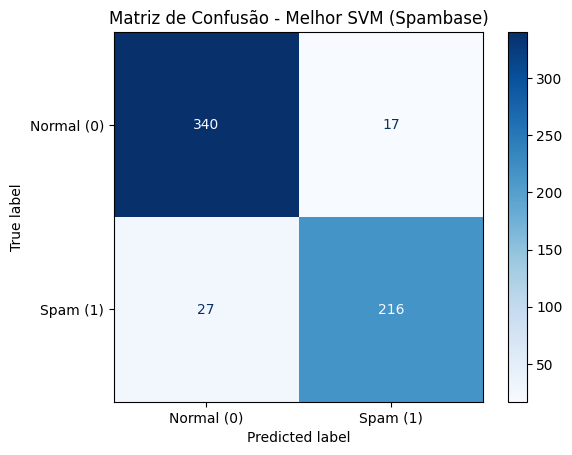

In [ ]:
# =====================================================================
# ETAPA 5: Avaliação do Melhor Modelo SVM
# =====================================================================
print("\n=== AVALIAÇÃO DETALHADA: SVM OTIMIZADO ===")

# Pegando o modelo campeão do GridSearch
melhor_svm = svm_grid.best_estimator_

# Fazendo previsões
prev_otimizada = melhor_svm.predict(X_test_scaled)
print(f"Acurácia do SVM Otimizado: {accuracy_score(y_test, prev_otimizada) * 100:.2f}%\n")

# Relatório de Classificação
print("Relatório de Classificação (0: E-mail Normal, 1: Spam):")
print(classification_report(y_test, prev_otimizada))

# Plotando a Matriz de Confusão
print("Gerando Matriz de Confusão visual...")
disp = ConfusionMatrixDisplay.from_estimator(
    melhor_svm, X_test_scaled, y_test,
    display_labels=['Normal (0)', 'Spam (1)'],
    cmap='Blues'
)
plt.title('Matriz de Confusão - Melhor SVM (Spambase)')
plt.show()